# Steering All-Traces Overview

Broad first-pass notebook for the raw steering export.
The goal is to reconstruct the full initial picture from raw clean and steered logits, before narrower follow-up analysis.

In [4]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

In [5]:
LETTERS = ["A", "B", "C", "D", "E"]
RUN_DIR = Path(r"C:\Users\mikol\OneDrive\Pulpit\Praca Magisterska\data\20260525-215511_Qwen-Qwen2.5-3B-Instruct_csqa_steering_all_traces")

In [6]:
baseline_df = pd.read_parquet(RUN_DIR / "steering_baseline.parquet")
results_df = pd.read_parquet(RUN_DIR / "steering_results.parquet")
direction_df = pd.read_parquet(RUN_DIR / "steering_direction_metadata.parquet")

with open(RUN_DIR / "run_config.json", "r", encoding="utf-8") as f:
    run_config = json.load(f)

## Reconstruction Helpers

Everything below is derived from the raw exported logits and best non-choice values.

In [7]:
def logits_to_numpy(frame, prefix):
    return frame[[
        f"{prefix}logit_A",
        f"{prefix}logit_B",
        f"{prefix}logit_C",
        f"{prefix}logit_D",
        f"{prefix}logit_E",
    ]].to_numpy(dtype=np.float64)


def softmax_probs(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(shifted)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)


def normalized_entropy(probabilities):
    entropy = -(probabilities * np.log(np.clip(probabilities, 1e-12, None))).sum(axis=1)
    return entropy / np.log(probabilities.shape[1])


def top1_top2_gap(logits):
    sorted_logits = np.sort(logits, axis=1)
    return sorted_logits[:, -1] - sorted_logits[:, -2]


def argmax_choice(logits):
    return logits.argmax(axis=1).astype(np.int64)

In [8]:
clean_logits = logits_to_numpy(baseline_df, "clean_")
clean_probs = softmax_probs(clean_logits)
baseline_df["clean_predicted_choice_idx"] = argmax_choice(clean_logits)
baseline_df["clean_is_correct"] = baseline_df["clean_predicted_choice_idx"].eq(baseline_df["true_choice_idx"])
baseline_df["clean_answer_choice_entropy_normalized"] = normalized_entropy(clean_probs)
baseline_df["clean_answer_choice_top1_top2_logit_gap"] = top1_top2_gap(clean_logits)
baseline_df["clean_best_choice_logit"] = clean_logits.max(axis=1)
baseline_df["clean_best_choice_minus_best_non_choice_logit"] = (
    baseline_df["clean_best_choice_logit"] - baseline_df["clean_best_non_choice_logit"]
)

steered_logits = logits_to_numpy(results_df, "steered_")
steered_probs = softmax_probs(steered_logits)
results_df["steered_predicted_choice_idx"] = argmax_choice(steered_logits)
results_df["steered_answer_choice_entropy_normalized"] = normalized_entropy(steered_probs)
results_df["steered_answer_choice_top1_top2_logit_gap"] = top1_top2_gap(steered_logits)
results_df["steered_best_choice_logit"] = steered_logits.max(axis=1)
results_df["steered_best_choice_minus_best_non_choice_logit"] = (
    results_df["steered_best_choice_logit"] - results_df["steered_best_non_choice_logit"]
)

In [9]:
analysis_df = results_df.merge(
    baseline_df,
    on="example_id",
    how="left",
    validate="many_to_one",
).copy()

analysis_df["steered_is_correct"] = analysis_df["steered_predicted_choice_idx"].eq(analysis_df["true_choice_idx"])
analysis_df["prediction_changed"] = analysis_df["steered_predicted_choice_idx"].ne(analysis_df["clean_predicted_choice_idx"])
analysis_df["rescued_error"] = (~analysis_df["clean_is_correct"]) & analysis_df["steered_is_correct"]
analysis_df["harmed_correct"] = analysis_df["clean_is_correct"] & (~analysis_df["steered_is_correct"])
analysis_df["originally_correct"] = analysis_df["clean_is_correct"].astype(int)
analysis_df["originally_incorrect"] = (~analysis_df["clean_is_correct"]).astype(int)
analysis_df["delta_answer_choice_entropy_normalized"] = (
    analysis_df["steered_answer_choice_entropy_normalized"] - analysis_df["clean_answer_choice_entropy_normalized"]
)
analysis_df["delta_answer_choice_top1_top2_logit_gap"] = (
    analysis_df["steered_answer_choice_top1_top2_logit_gap"] - analysis_df["clean_answer_choice_top1_top2_logit_gap"]
)
analysis_df["delta_best_choice_minus_best_non_choice_logit"] = (
    analysis_df["steered_best_choice_minus_best_non_choice_logit"] - analysis_df["clean_best_choice_minus_best_non_choice_logit"]
)
analysis_df["trace_bucket"] = np.where(
    analysis_df["clean_is_correct"],
    "originally_correct",
    "originally_incorrect",
)

method_order = ["contrastive_mean_direction", "probe_normal_direction"]
scale_order = sorted(analysis_df["scale"].drop_duplicates().tolist())

## Run Overview

In [10]:
overview_df = pd.DataFrame([
    {
        "model_id": run_config["model_id"],
        "train_split": run_config["train_split"],
        "target_split": run_config["target_split"],
        "n_target_examples": run_config["num_target_examples"],
        "n_layers": run_config["num_layers"],
        "methods": ", ".join(run_config["methods"]),
        "scales": ", ".join(str(x) for x in run_config["steering_scales"]),
        "clean_accuracy": baseline_df["clean_is_correct"].mean(),
    }
])

display(overview_df)
display(direction_df.round(4))

,model_id,train_split,target_split,n_target_examples,n_layers,methods,scales,clean_accuracy
0,Qwen/Qwen2.5-3B-Instruct,train,validation,1221,36,"contrastive_mean_direction, probe_normal_direc...","0.5, 1.0, 1.5, 2.0, 3.0, 4.0",0.802621


,method,raw_direction_norm,probe_train_accuracy,layer_number,n_train_correct_used,n_train_incorrect_used
0,contrastive_mean_direction,0.0257,NaN,1,7544,2197
1,probe_normal_direction,135.4054,0.7636,1,7544,2197
2,contrastive_mean_direction,0.0350,NaN,2,7544,2197
3,probe_normal_direction,118.2545,0.7921,2,7544,2197
4,contrastive_mean_direction,0.0503,NaN,3,7544,2197
...,...,...,...,...,...,...
67,probe_normal_direction,1.5899,0.8454,34,7544,2197
68,contrastive_mean_direction,15.7527,NaN,35,7544,2197
69,probe_normal_direction,1.5574,0.8222,35,7544,2197
70,contrastive_mean_direction,12.5901,NaN,36,7544,2197


## Baseline Reconstruction

In [11]:
baseline_summary_df = pd.DataFrame([
    {
        "n_examples": len(baseline_df),
        "n_originally_correct": int(baseline_df["clean_is_correct"].sum()),
        "n_originally_incorrect": int((~baseline_df["clean_is_correct"]).sum()),
        "clean_accuracy": baseline_df["clean_is_correct"].mean(),
        "mean_clean_entropy": baseline_df["clean_answer_choice_entropy_normalized"].mean(),
        "mean_clean_top1_top2_gap": baseline_df["clean_answer_choice_top1_top2_logit_gap"].mean(),
        "mean_clean_best_choice_minus_best_non_choice_logit": baseline_df["clean_best_choice_minus_best_non_choice_logit"].mean(),
    }
])

display(baseline_summary_df.round(4))

,n_examples,n_originally_correct,n_originally_incorrect,clean_accuracy,mean_clean_entropy,mean_clean_top1_top2_gap,mean_clean_best_choice_minus_best_non_choice_logit
0,1221,980,241,0.8026,0.0393,9.8771,9.2439


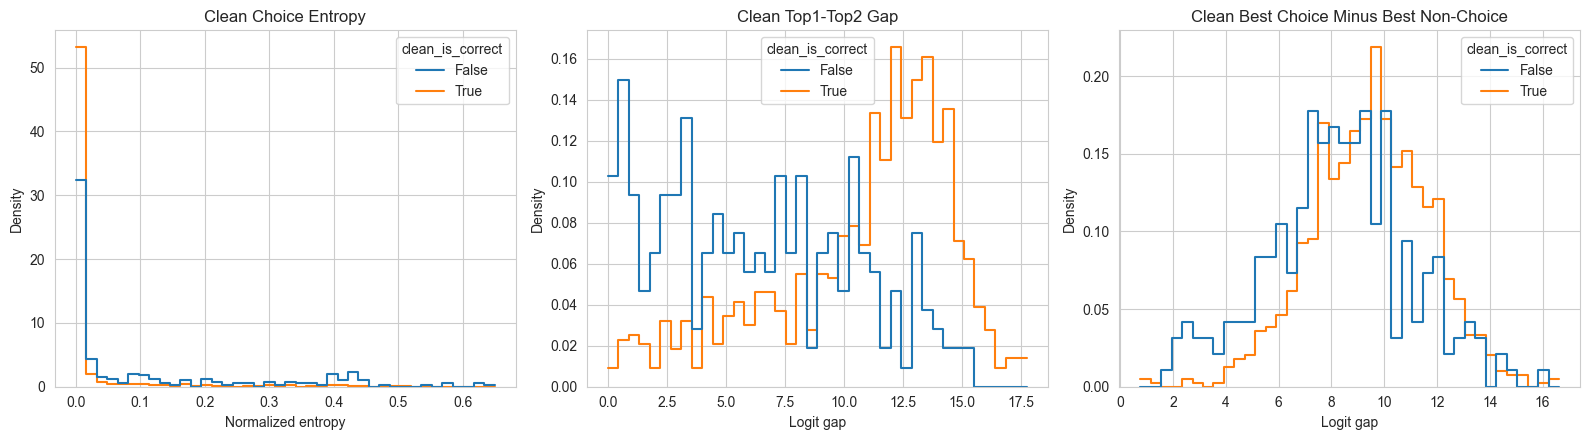

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(
    data=baseline_df,
    x="clean_answer_choice_entropy_normalized",
    hue="clean_is_correct",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=axes[0],
)
axes[0].set_title("Clean Choice Entropy")
axes[0].set_xlabel("Normalized entropy")

sns.histplot(
    data=baseline_df,
    x="clean_answer_choice_top1_top2_logit_gap",
    hue="clean_is_correct",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=axes[1],
)
axes[1].set_title("Clean Top1-Top2 Gap")
axes[1].set_xlabel("Logit gap")

sns.histplot(
    data=baseline_df,
    x="clean_best_choice_minus_best_non_choice_logit",
    hue="clean_is_correct",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    ax=axes[2],
)
axes[2].set_title("Clean Best Choice Minus Best Non-Choice")
axes[2].set_xlabel("Logit gap")

plt.tight_layout()
plt.show()

## Ungated Steering Summary

In [13]:
summary_df = (
    analysis_df.groupby(["method", "layer_number", "scale"], as_index=False)
    .agg(
        n_examples=("example_id", "size"),
        clean_accuracy=("clean_is_correct", "mean"),
        steered_accuracy=("steered_is_correct", "mean"),
        n_originally_correct=("originally_correct", "sum"),
        n_originally_incorrect=("originally_incorrect", "sum"),
        n_prediction_changed=("prediction_changed", "sum"),
        change_rate=("prediction_changed", "mean"),
        n_rescued=("rescued_error", "sum"),
        n_harmed=("harmed_correct", "sum"),
        mean_delta_entropy=("delta_answer_choice_entropy_normalized", "mean"),
        mean_delta_gap=("delta_answer_choice_top1_top2_logit_gap", "mean"),
        mean_delta_choice_vs_nonchoice=("delta_best_choice_minus_best_non_choice_logit", "mean"),
        mean_token_hidden_rms=("token_hidden_rms", "mean"),
        mean_token_hidden_l2_norm=("token_hidden_l2_norm", "mean"),
        mean_direction_l2_norm=("direction_l2_norm", "mean"),
        mean_delta_l2_norm=("delta_l2_norm", "mean"),
        mean_delta_over_token_hidden_l2=("delta_over_token_hidden_l2", "mean"),
        p90_delta_over_token_hidden_l2=("delta_over_token_hidden_l2", lambda s: float(np.quantile(s, 0.90))),
    )
)
summary_df["rescue_rate_bad"] = summary_df["n_rescued"] / summary_df["n_originally_incorrect"]
summary_df["harm_rate_good"] = summary_df["n_harmed"] / summary_df["n_originally_correct"]
summary_df["net_gain_count"] = summary_df["n_rescued"] - summary_df["n_harmed"]
summary_df["net_gain_rate"] = summary_df["net_gain_count"] / summary_df["n_examples"]
summary_df["accuracy_delta"] = summary_df["steered_accuracy"] - summary_df["clean_accuracy"]

best_configs_df = summary_df.sort_values(
    ["net_gain_count", "steered_accuracy", "n_rescued", "n_harmed"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

display(best_configs_df.head(20).round(4))

,method,layer_number,scale,n_examples,clean_accuracy,steered_accuracy,n_originally_correct,n_originally_incorrect,n_prediction_changed,change_rate,n_rescued,n_harmed,mean_delta_entropy,mean_delta_gap,mean_delta_choice_vs_nonchoice,mean_token_hidden_rms,mean_token_hidden_l2_norm,mean_direction_l2_norm,mean_delta_l2_norm,mean_delta_over_token_hidden_l2,p90_delta_over_token_hidden_l2,rescue_rate_bad,harm_rate_good,net_gain_count,net_gain_rate,accuracy_delta
0,contrastive_mean_direction,27,3.0,1221,0.8026,0.8075,980,241,29,0.0238,14,8,-0.0067,0.6051,-0.2542,1.9833,89.7523,0.9999,5.9493,0.0663,0.0663,0.0581,0.0082,6,0.0049,0.0049
1,contrastive_mean_direction,30,4.0,1221,0.8026,0.8075,980,241,25,0.0205,13,7,-0.0042,0.7228,-0.3408,2.8439,128.6985,1.0001,11.3761,0.0884,0.0884,0.0539,0.0071,6,0.0049,0.0049
2,contrastive_mean_direction,29,3.0,1221,0.8026,0.8075,980,241,23,0.0188,12,6,-0.0033,0.4685,-0.3049,2.6570,120.2440,1.0001,7.9721,0.0663,0.0663,0.0498,0.0061,6,0.0049,0.0049
3,contrastive_mean_direction,13,4.0,1221,0.8026,0.8067,980,241,20,0.0164,11,6,-0.0025,0.5649,-0.4018,1.0206,46.1853,1.0000,4.0821,0.0884,0.0884,0.0456,0.0061,5,0.0041,0.0041
4,contrastive_mean_direction,15,4.0,1221,0.8026,0.8067,980,241,21,0.0172,10,5,-0.0019,0.5298,-0.4833,1.1435,51.7490,1.0001,4.5743,0.0884,0.0884,0.0415,0.0051,5,0.0041,0.0041
5,contrastive_mean_direction,17,3.0,1221,0.8026,0.8067,980,241,21,0.0172,10,5,-0.0017,0.2653,-0.2364,1.1852,53.6347,0.9999,3.5552,0.0663,0.0663,0.0415,0.0051,5,0.0041,0.0041
6,contrastive_mean_direction,18,4.0,1221,0.8026,0.8067,980,241,16,0.0131,9,4,-0.0012,0.3034,-0.2388,1.1691,52.9090,1.0000,4.6764,0.0884,0.0884,0.0373,0.0041,5,0.0041,0.0041
7,contrastive_mean_direction,26,4.0,1221,0.8026,0.8059,980,241,27,0.0221,12,8,-0.0043,0.4925,-0.4190,1.7427,78.8651,1.0002,6.9719,0.0884,0.0884,0.0498,0.0082,4,0.0033,0.0033
8,contrastive_mean_direction,32,4.0,1221,0.8026,0.8059,980,241,25,0.0205,12,8,-0.0042,0.7106,-0.3183,4.1883,189.5421,1.0000,16.7527,0.0884,0.0884,0.0498,0.0082,4,0.0033,0.0033
9,contrastive_mean_direction,27,2.0,1221,0.8026,0.8059,980,241,21,0.0172,11,7,-0.0057,0.4230,-0.1553,1.9833,89.7523,0.9999,3.9662,0.0442,0.0442,0.0456,0.0071,4,0.0033,0.0033


In [14]:
method_scale_summary_df = (
    summary_df.groupby(["method", "scale"], as_index=False)
    .agg(
        mean_clean_accuracy=("clean_accuracy", "mean"),
        mean_steered_accuracy=("steered_accuracy", "mean"),
        mean_rescue_rate_bad=("rescue_rate_bad", "mean"),
        mean_harm_rate_good=("harm_rate_good", "mean"),
        mean_net_gain_rate=("net_gain_rate", "mean"),
        mean_accuracy_delta=("accuracy_delta", "mean"),
        positive_net_layers=("net_gain_count", lambda s: int((s > 0).sum())),
        zero_net_layers=("net_gain_count", lambda s: int((s == 0).sum())),
        negative_net_layers=("net_gain_count", lambda s: int((s < 0).sum())),
    )
)

display(method_scale_summary_df.round(4))

,method,scale,mean_clean_accuracy,mean_steered_accuracy,mean_rescue_rate_bad,mean_harm_rate_good,mean_net_gain_rate,mean_accuracy_delta,positive_net_layers,zero_net_layers,negative_net_layers
0,contrastive_mean_direction,0.5,0.8026,0.8016,0.0248,0.0073,-0.0010,-0.0010,1,10,25
1,contrastive_mean_direction,1.0,0.8026,0.8026,0.0270,0.0066,0.0000,0.0000,9,15,12
2,contrastive_mean_direction,1.5,0.8026,0.8028,0.0284,0.0067,0.0002,0.0002,15,12,9
3,contrastive_mean_direction,2.0,0.8026,0.8030,0.0294,0.0067,0.0004,0.0004,19,6,11
4,contrastive_mean_direction,3.0,0.8026,0.8039,0.0350,0.0070,0.0013,0.0013,25,6,5
5,contrastive_mean_direction,4.0,0.8026,0.8040,0.0377,0.0076,0.0013,0.0013,23,5,8
6,probe_normal_direction,0.5,0.8026,0.8016,0.0255,0.0075,-0.0010,-0.0010,1,7,28
7,probe_normal_direction,1.0,0.8026,0.8019,0.0260,0.0073,-0.0008,-0.0008,5,4,27
8,probe_normal_direction,1.5,0.8026,0.8022,0.0272,0.0072,-0.0004,-0.0004,6,10,20
9,probe_normal_direction,2.0,0.8026,0.8019,0.0269,0.0075,-0.0007,-0.0007,7,8,21


## Heatmaps By Method

In [15]:
def heatmap_by_method(value_col, title, cmap="viridis", center=None, fmt=".3f"):
    fig, axes = plt.subplots(1, len(method_order), figsize=(8 * len(method_order), 5), sharey=True)
    if len(method_order) == 1:
        axes = [axes]
    for ax, method in zip(axes, method_order):
        pivot = (
            summary_df.loc[summary_df["method"].eq(method)]
            .pivot(index="scale", columns="layer_number", values=value_col)
            .reindex(index=scale_order)
        )
        sns.heatmap(pivot, cmap=cmap, center=center, ax=ax)
        ax.set_title(f"{method}: {title}")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Scale")
    plt.tight_layout()
    plt.show()

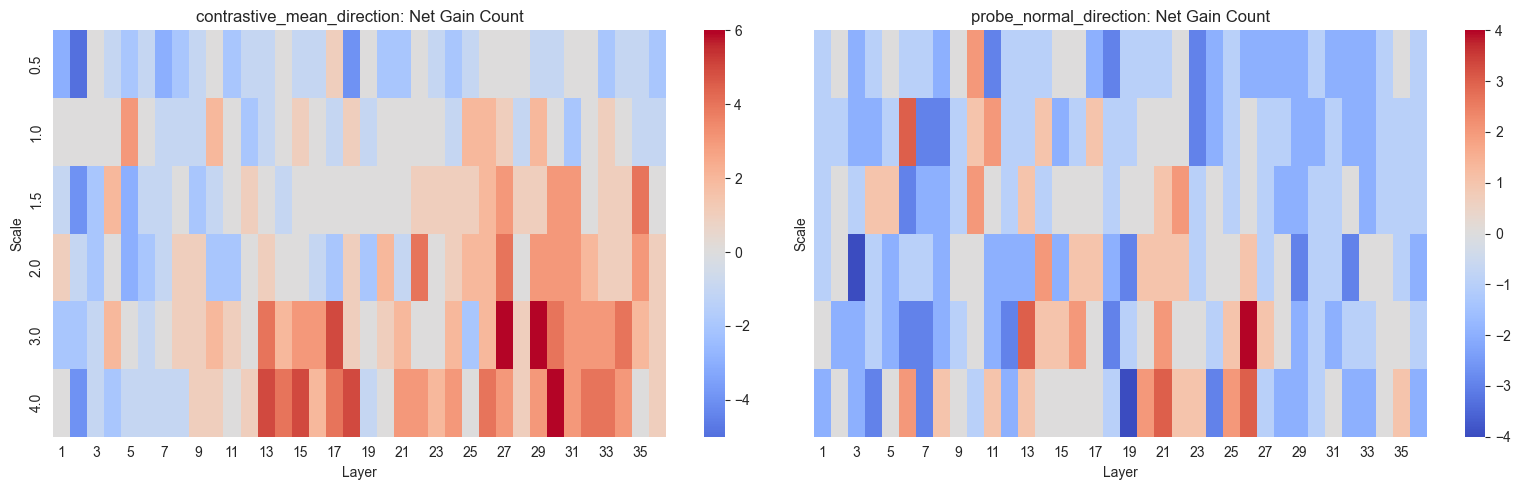

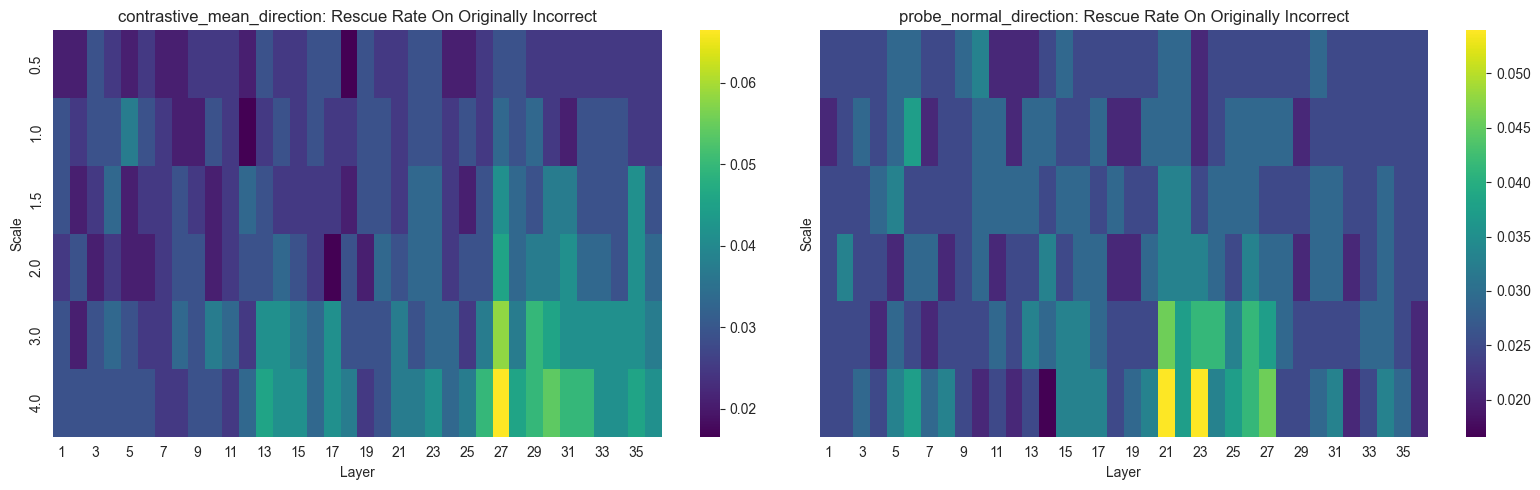

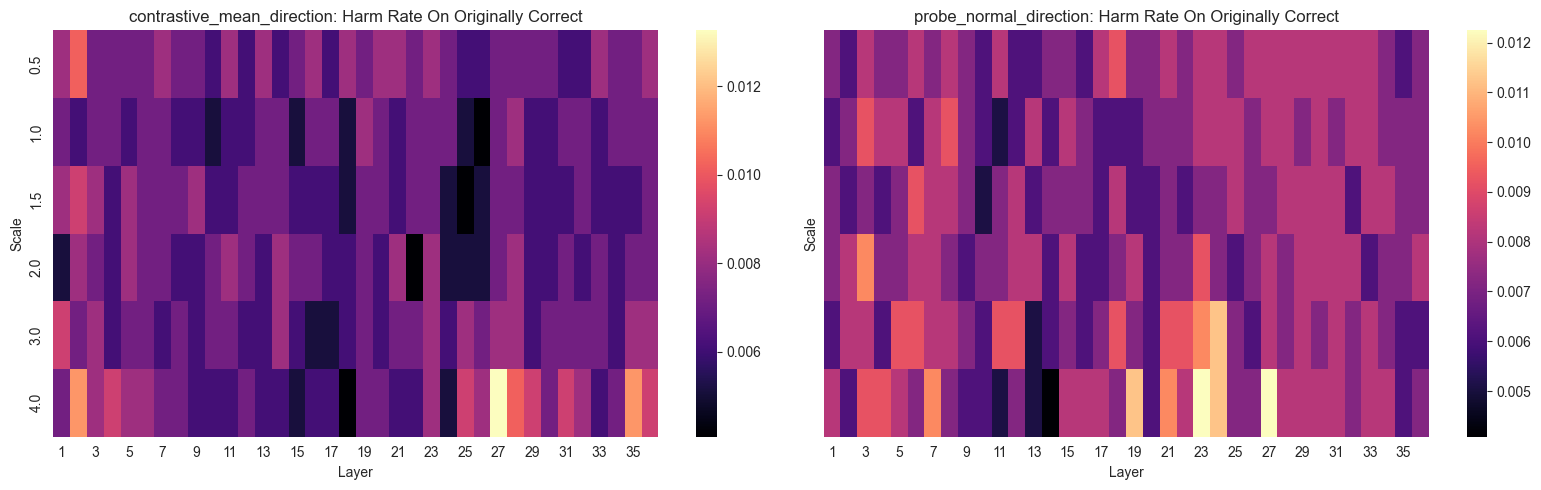

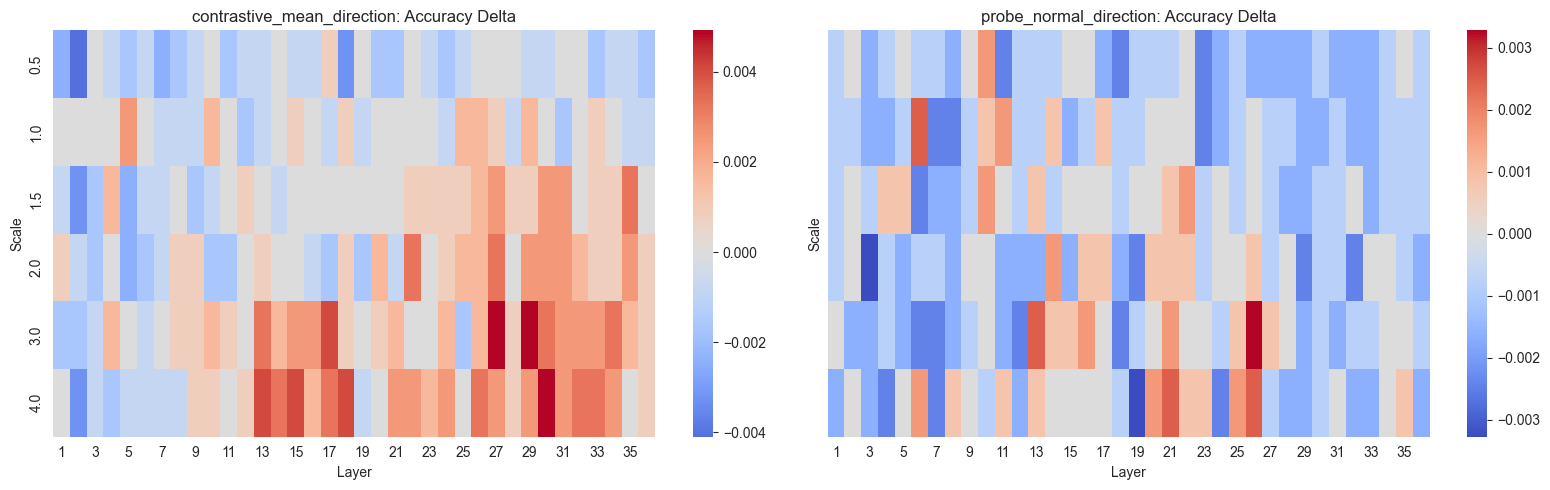

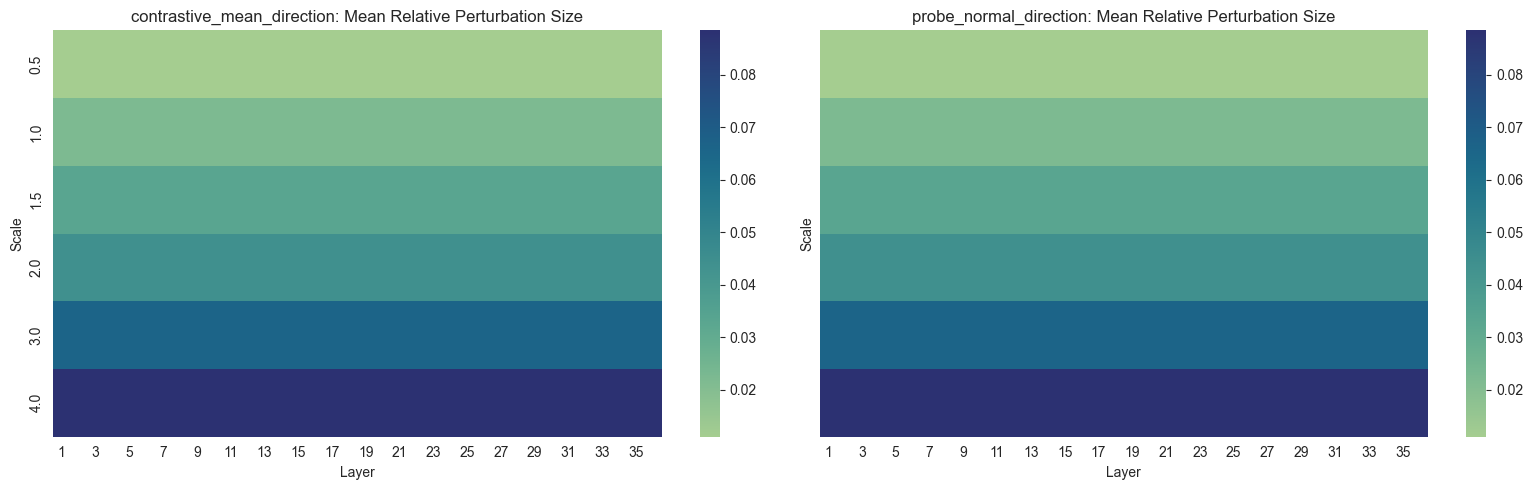

In [16]:
heatmap_by_method("net_gain_count", "Net Gain Count", cmap="coolwarm", center=0.0)
heatmap_by_method("rescue_rate_bad", "Rescue Rate On Originally Incorrect", cmap="viridis")
heatmap_by_method("harm_rate_good", "Harm Rate On Originally Correct", cmap="magma")
heatmap_by_method("accuracy_delta", "Accuracy Delta", cmap="coolwarm", center=0.0)
heatmap_by_method("mean_delta_over_token_hidden_l2", "Mean Relative Perturbation Size", cmap="crest")

## Best-Region View

In [17]:
top_net_configs_df = (
    summary_df.sort_values(["net_gain_count", "accuracy_delta", "n_rescued", "n_harmed"], ascending=[False, False, False, True])
    .groupby("method")
    .head(8)
    .reset_index(drop=True)
)

display(top_net_configs_df.round(4))

,method,layer_number,scale,n_examples,clean_accuracy,steered_accuracy,n_originally_correct,n_originally_incorrect,n_prediction_changed,change_rate,n_rescued,n_harmed,mean_delta_entropy,mean_delta_gap,mean_delta_choice_vs_nonchoice,mean_token_hidden_rms,mean_token_hidden_l2_norm,mean_direction_l2_norm,mean_delta_l2_norm,mean_delta_over_token_hidden_l2,p90_delta_over_token_hidden_l2,rescue_rate_bad,harm_rate_good,net_gain_count,net_gain_rate,accuracy_delta
0,contrastive_mean_direction,27,3.0,1221,0.8026,0.8075,980,241,29,0.0238,14,8,-0.0067,0.6051,-0.2542,1.9833,89.7523,0.9999,5.9493,0.0663,0.0663,0.0581,0.0082,6,0.0049,0.0049
1,contrastive_mean_direction,30,4.0,1221,0.8026,0.8075,980,241,25,0.0205,13,7,-0.0042,0.7228,-0.3408,2.8439,128.6985,1.0001,11.3761,0.0884,0.0884,0.0539,0.0071,6,0.0049,0.0049
2,contrastive_mean_direction,29,3.0,1221,0.8026,0.8075,980,241,23,0.0188,12,6,-0.0033,0.4685,-0.3049,2.6570,120.2440,1.0001,7.9721,0.0663,0.0663,0.0498,0.0061,6,0.0049,0.0049
3,contrastive_mean_direction,13,4.0,1221,0.8026,0.8067,980,241,20,0.0164,11,6,-0.0025,0.5649,-0.4018,1.0206,46.1853,1.0000,4.0821,0.0884,0.0884,0.0456,0.0061,5,0.0041,0.0041
4,contrastive_mean_direction,15,4.0,1221,0.8026,0.8067,980,241,21,0.0172,10,5,-0.0019,0.5298,-0.4833,1.1435,51.7490,1.0001,4.5743,0.0884,0.0884,0.0415,0.0051,5,0.0041,0.0041
5,contrastive_mean_direction,17,3.0,1221,0.8026,0.8067,980,241,21,0.0172,10,5,-0.0017,0.2653,-0.2364,1.1852,53.6347,0.9999,3.5552,0.0663,0.0663,0.0415,0.0051,5,0.0041,0.0041
6,contrastive_mean_direction,18,4.0,1221,0.8026,0.8067,980,241,16,0.0131,9,4,-0.0012,0.3034,-0.2388,1.1691,52.9090,1.0000,4.6764,0.0884,0.0884,0.0373,0.0041,5,0.0041,0.0041
7,contrastive_mean_direction,26,4.0,1221,0.8026,0.8059,980,241,27,0.0221,12,8,-0.0043,0.4925,-0.4190,1.7427,78.8651,1.0002,6.9719,0.0884,0.0884,0.0498,0.0082,4,0.0033,0.0033
8,probe_normal_direction,26,3.0,1221,0.8026,0.8059,980,241,24,0.0197,10,6,-0.0010,0.0979,-0.1329,1.7427,78.8651,0.9999,5.2273,0.0663,0.0663,0.0415,0.0061,4,0.0033,0.0033
9,probe_normal_direction,21,4.0,1221,0.8026,0.8051,980,241,28,0.0229,13,10,-0.0025,0.1507,0.0316,1.2119,54.8462,0.9999,4.8474,0.0884,0.0884,0.0539,0.0102,3,0.0025,0.0025


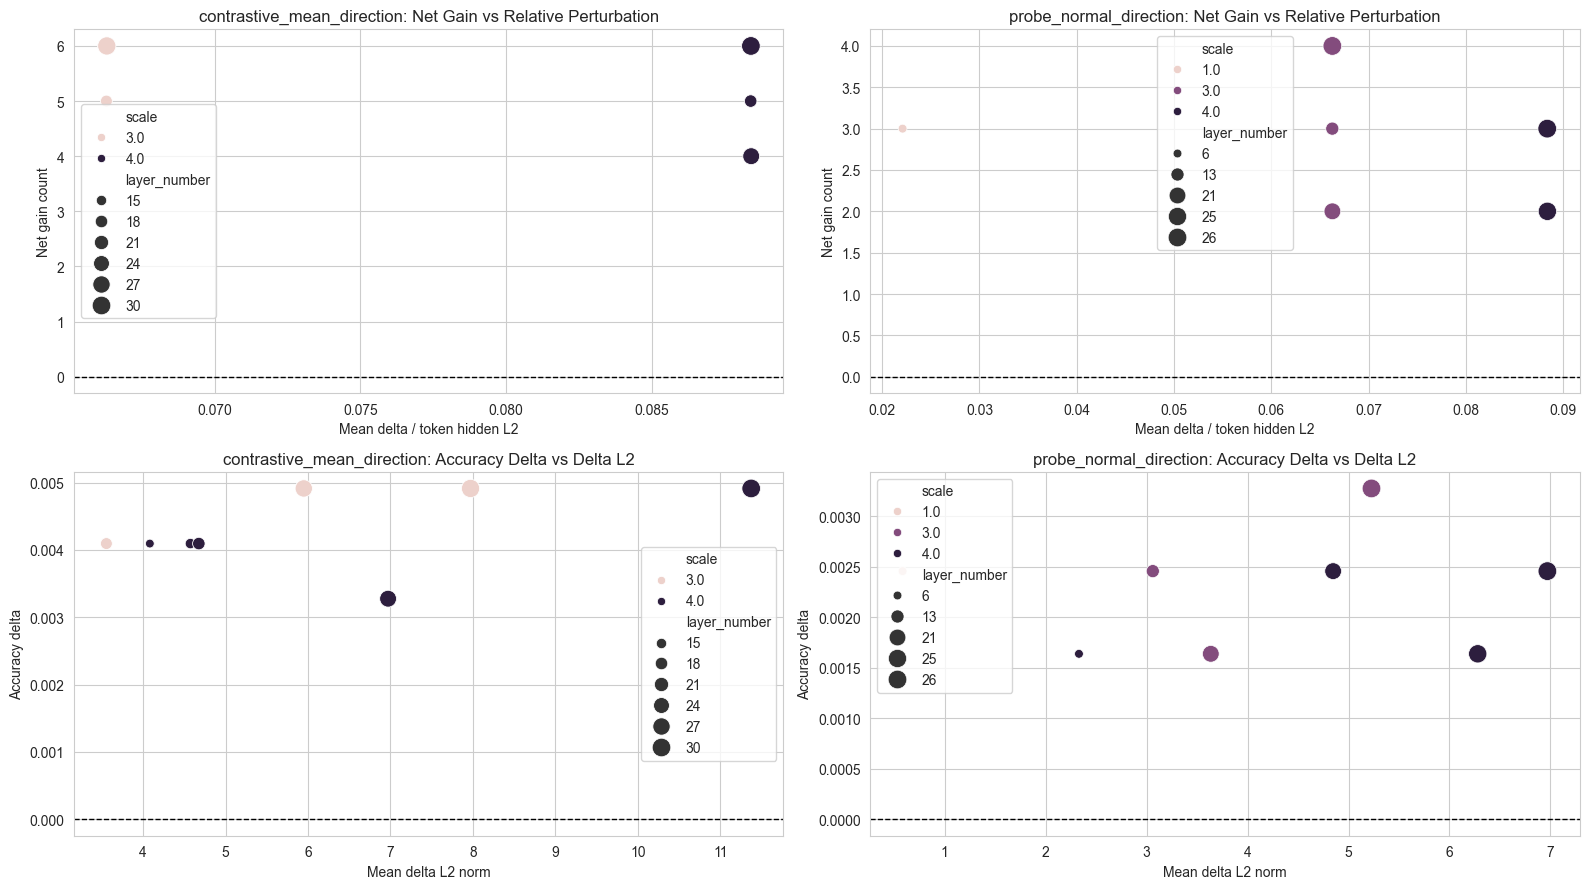

In [18]:
fig, axes = plt.subplots(2, len(method_order), figsize=(8 * len(method_order), 9), sharex=False)

for col, method in enumerate(method_order):
    method_part = top_net_configs_df.loc[top_net_configs_df["method"].eq(method)].copy()
    method_part = method_part.sort_values(["layer_number", "scale"]).reset_index(drop=True)

    sns.scatterplot(
        data=method_part,
        x="mean_delta_over_token_hidden_l2",
        y="net_gain_count",
        hue="scale",
        size="layer_number",
        sizes=(40, 180),
        ax=axes[0, col],
    )
    axes[0, col].axhline(0.0, color="black", linestyle="--", linewidth=1)
    axes[0, col].set_title(f"{method}: Net Gain vs Relative Perturbation")
    axes[0, col].set_xlabel("Mean delta / token hidden L2")
    axes[0, col].set_ylabel("Net gain count")

    sns.scatterplot(
        data=method_part,
        x="mean_delta_l2_norm",
        y="accuracy_delta",
        hue="scale",
        size="layer_number",
        sizes=(40, 180),
        ax=axes[1, col],
    )
    axes[1, col].axhline(0.0, color="black", linestyle="--", linewidth=1)
    axes[1, col].set_title(f"{method}: Accuracy Delta vs Delta L2")
    axes[1, col].set_xlabel("Mean delta L2 norm")
    axes[1, col].set_ylabel("Accuracy delta")

plt.tight_layout()
plt.show()

## Dose Response For Strong Layers

In [19]:
layer_candidates_df = (
    summary_df.groupby(["method", "layer_number"], as_index=False)
    .agg(max_net_gain_count=("net_gain_count", "max"), max_accuracy_delta=("accuracy_delta", "max"))
    .sort_values(["method", "max_net_gain_count", "max_accuracy_delta"], ascending=[True, False, False])
)

top_layers_df = layer_candidates_df.groupby("method").head(4).reset_index(drop=True)
display(top_layers_df.round(4))

,method,layer_number,max_net_gain_count,max_accuracy_delta
0,contrastive_mean_direction,27,6,0.0049
1,contrastive_mean_direction,29,6,0.0049
2,contrastive_mean_direction,30,6,0.0049
3,contrastive_mean_direction,13,5,0.0041
4,probe_normal_direction,26,4,0.0033
5,probe_normal_direction,6,3,0.0025
6,probe_normal_direction,13,3,0.0025
7,probe_normal_direction,21,3,0.0025


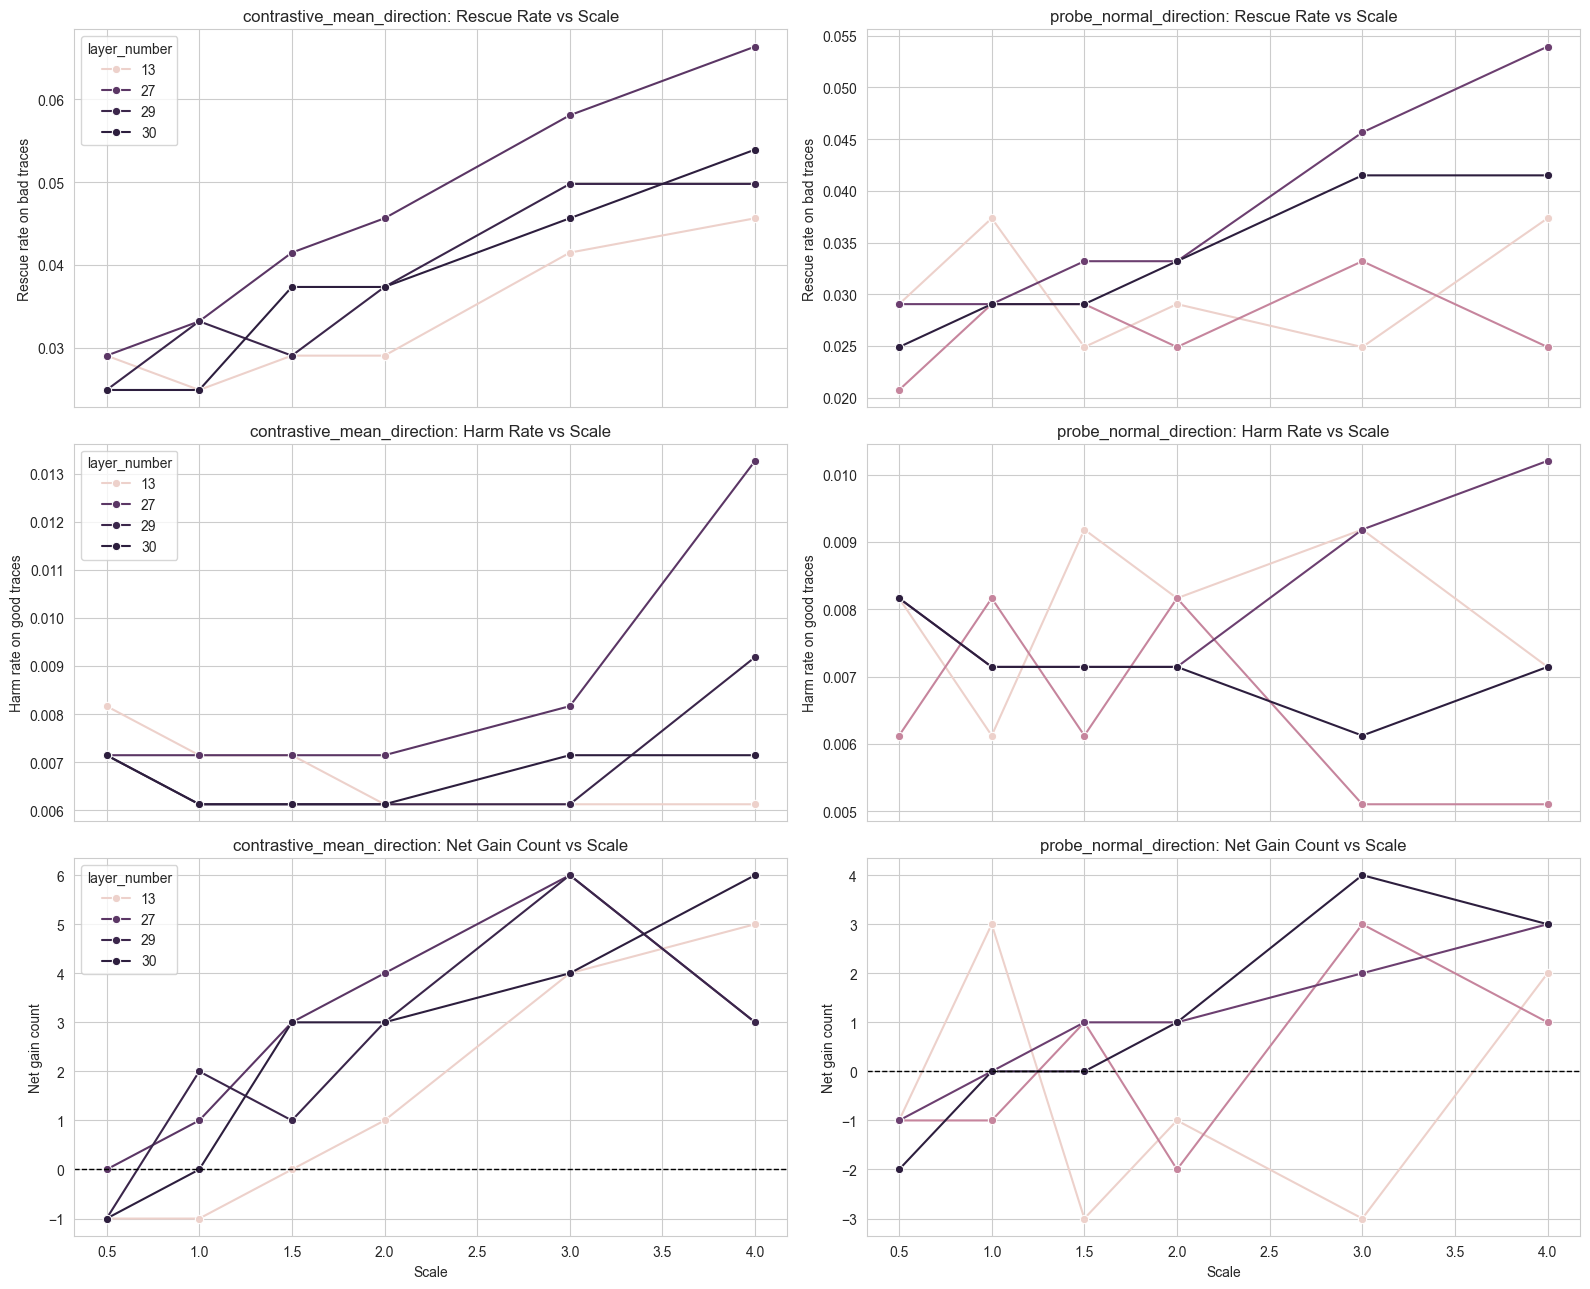

In [20]:
selected_summary_df = summary_df.merge(
    top_layers_df[["method", "layer_number"]],
    on=["method", "layer_number"],
    how="inner",
    validate="many_to_many",
)

fig, axes = plt.subplots(3, len(method_order), figsize=(8 * len(method_order), 13), sharex=True)

for col, method in enumerate(method_order):
    method_part = selected_summary_df.loc[selected_summary_df["method"].eq(method)]

    sns.lineplot(
        data=method_part,
        x="scale",
        y="rescue_rate_bad",
        hue="layer_number",
        marker="o",
        ax=axes[0, col],
    )
    axes[0, col].set_title(f"{method}: Rescue Rate vs Scale")
    axes[0, col].set_ylabel("Rescue rate on bad traces")

    sns.lineplot(
        data=method_part,
        x="scale",
        y="harm_rate_good",
        hue="layer_number",
        marker="o",
        ax=axes[1, col],
    )
    axes[1, col].set_title(f"{method}: Harm Rate vs Scale")
    axes[1, col].set_ylabel("Harm rate on good traces")

    sns.lineplot(
        data=method_part,
        x="scale",
        y="net_gain_count",
        hue="layer_number",
        marker="o",
        ax=axes[2, col],
    )
    axes[2, col].axhline(0.0, color="black", linestyle="--", linewidth=1)
    axes[2, col].set_title(f"{method}: Net Gain Count vs Scale")
    axes[2, col].set_ylabel("Net gain count")
    axes[2, col].set_xlabel("Scale")

for row in range(3):
    for col in range(1, len(method_order)):
        if axes[row, col].legend_ is not None:
            axes[row, col].legend_.remove()

plt.tight_layout()
plt.show()

## Perturbation Size Distributions

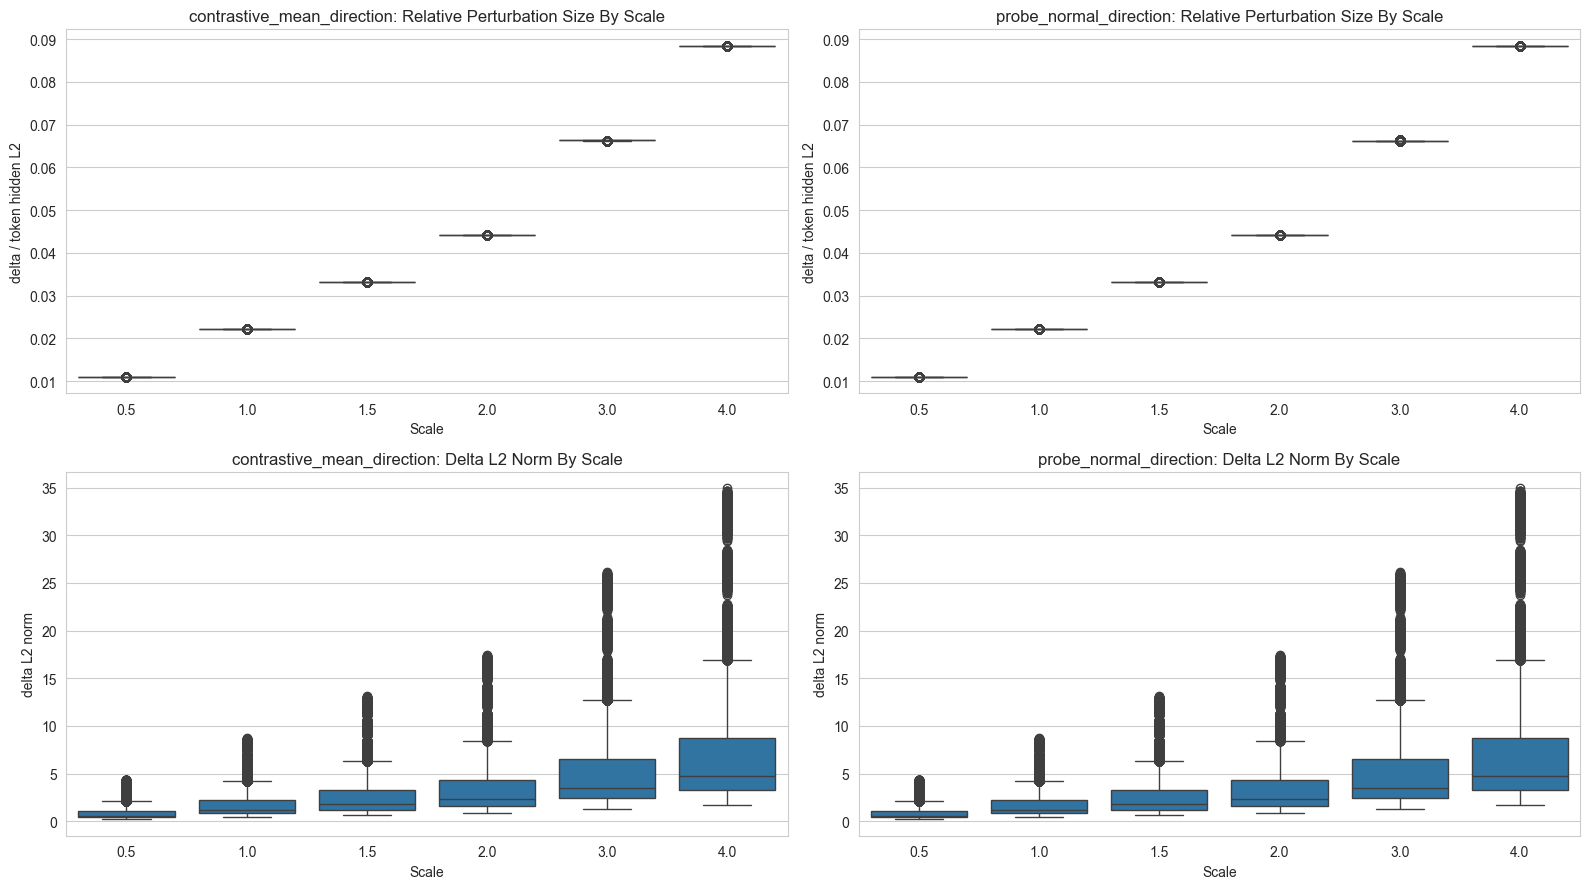

In [21]:
fig, axes = plt.subplots(2, len(method_order), figsize=(8 * len(method_order), 9), sharex=False)

for col, method in enumerate(method_order):
    method_part = analysis_df.loc[analysis_df["method"].eq(method)]

    sns.boxplot(
        data=method_part,
        x="scale",
        y="delta_over_token_hidden_l2",
        ax=axes[0, col],
    )
    axes[0, col].set_title(f"{method}: Relative Perturbation Size By Scale")
    axes[0, col].set_xlabel("Scale")
    axes[0, col].set_ylabel("delta / token hidden L2")

    sns.boxplot(
        data=method_part,
        x="scale",
        y="delta_l2_norm",
        ax=axes[1, col],
    )
    axes[1, col].set_title(f"{method}: Delta L2 Norm By Scale")
    axes[1, col].set_xlabel("Scale")
    axes[1, col].set_ylabel("delta L2 norm")

plt.tight_layout()
plt.show()

## Metric Shifts Under Steering

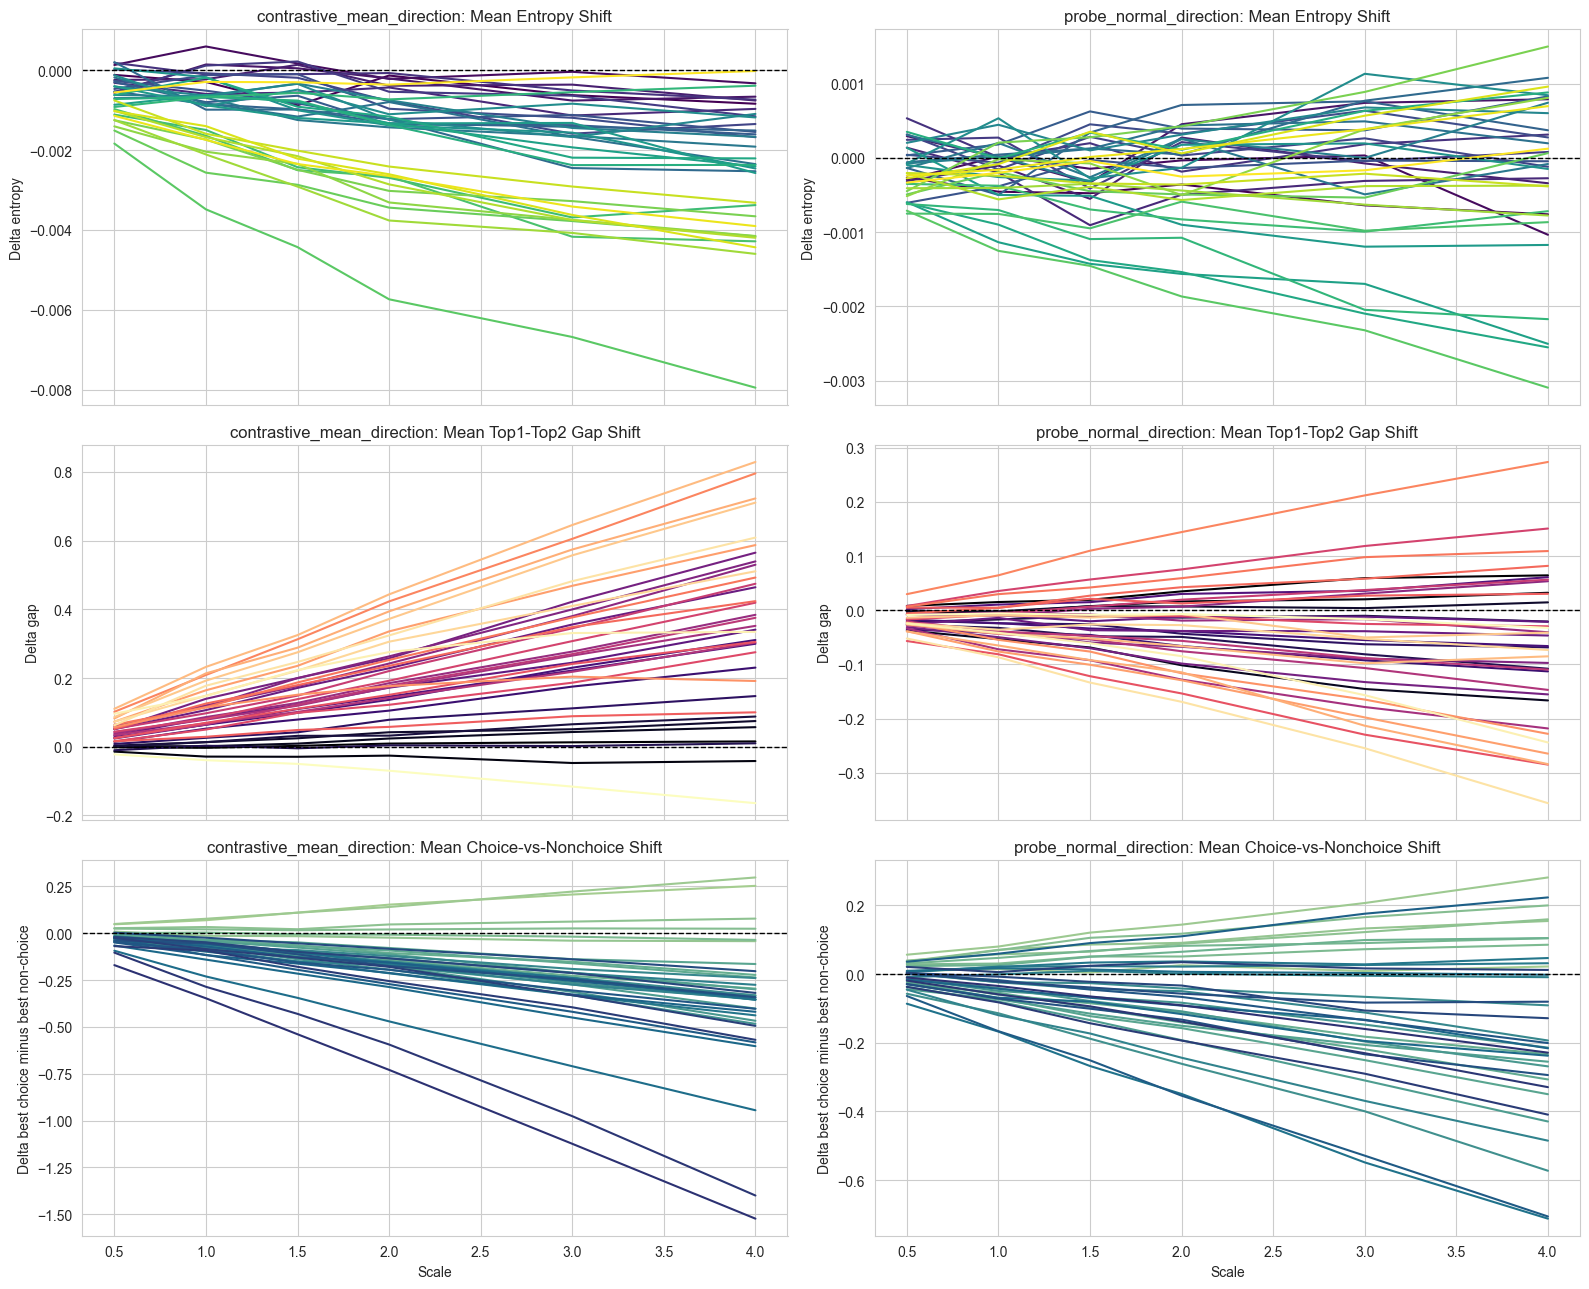

In [22]:
fig, axes = plt.subplots(3, len(method_order), figsize=(8 * len(method_order), 13), sharex=True)

for col, method in enumerate(method_order):
    method_part = summary_df.loc[summary_df["method"].eq(method)]

    sns.lineplot(
        data=method_part,
        x="scale",
        y="mean_delta_entropy",
        hue="layer_number",
        palette="viridis",
        legend=False,
        ax=axes[0, col],
    )
    axes[0, col].axhline(0.0, color="black", linestyle="--", linewidth=1)
    axes[0, col].set_title(f"{method}: Mean Entropy Shift")
    axes[0, col].set_ylabel("Delta entropy")

    sns.lineplot(
        data=method_part,
        x="scale",
        y="mean_delta_gap",
        hue="layer_number",
        palette="magma",
        legend=False,
        ax=axes[1, col],
    )
    axes[1, col].axhline(0.0, color="black", linestyle="--", linewidth=1)
    axes[1, col].set_title(f"{method}: Mean Top1-Top2 Gap Shift")
    axes[1, col].set_ylabel("Delta gap")

    sns.lineplot(
        data=method_part,
        x="scale",
        y="mean_delta_choice_vs_nonchoice",
        hue="layer_number",
        palette="crest",
        legend=False,
        ax=axes[2, col],
    )
    axes[2, col].axhline(0.0, color="black", linestyle="--", linewidth=1)
    axes[2, col].set_title(f"{method}: Mean Choice-vs-Nonchoice Shift")
    axes[2, col].set_ylabel("Delta best choice minus best non-choice")
    axes[2, col].set_xlabel("Scale")

plt.tight_layout()
plt.show()

## Prediction Change and Outcome Decomposition

In [23]:
outcome_summary_df = (
    summary_df[[
        "method",
        "layer_number",
        "scale",
        "n_prediction_changed",
        "change_rate",
        "n_rescued",
        "n_harmed",
        "net_gain_count",
    ]]
    .sort_values(["method", "net_gain_count", "n_prediction_changed"], ascending=[True, False, False])
    .reset_index(drop=True)
)

display(outcome_summary_df.head(30).round(4))

,method,layer_number,scale,n_prediction_changed,change_rate,n_rescued,n_harmed,net_gain_count
0,contrastive_mean_direction,27,3.0,29,0.0238,14,8,6
1,contrastive_mean_direction,30,4.0,25,0.0205,13,7,6
2,contrastive_mean_direction,29,3.0,23,0.0188,12,6,6
3,contrastive_mean_direction,15,4.0,21,0.0172,10,5,5
4,contrastive_mean_direction,17,3.0,21,0.0172,10,5,5
5,contrastive_mean_direction,13,4.0,20,0.0164,11,6,5
6,contrastive_mean_direction,18,4.0,16,0.0131,9,4,5
7,contrastive_mean_direction,26,4.0,27,0.0221,12,8,4
8,contrastive_mean_direction,32,4.0,25,0.0205,12,8,4
9,contrastive_mean_direction,30,3.0,23,0.0188,11,7,4


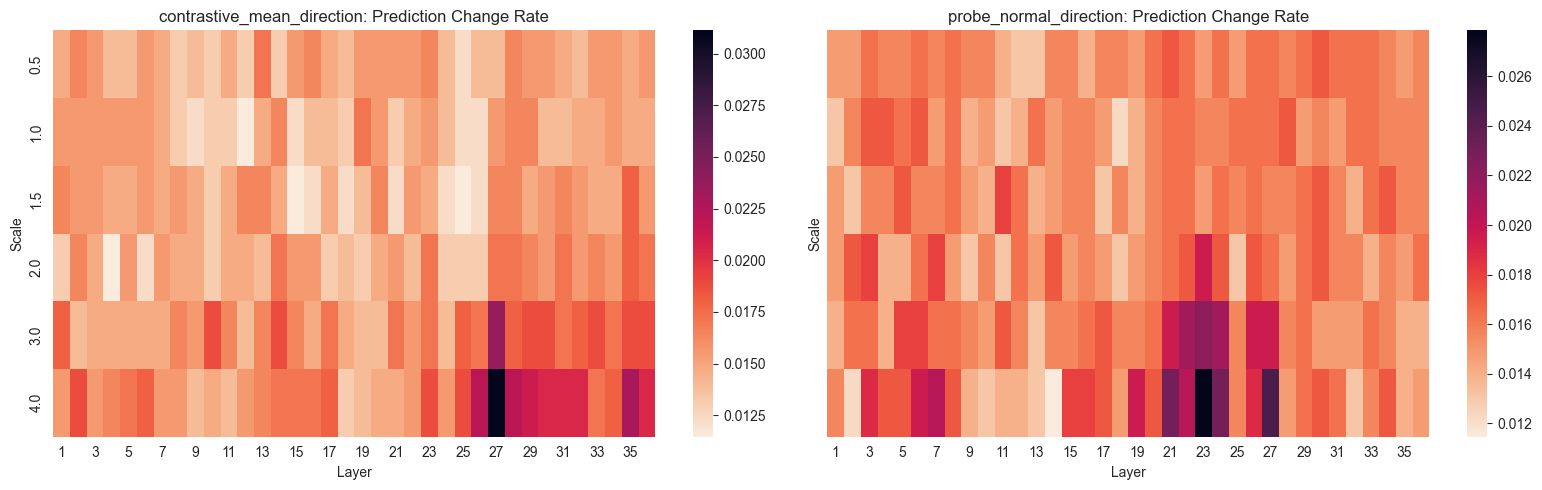

In [24]:
fig, axes = plt.subplots(1, len(method_order), figsize=(8 * len(method_order), 5), sharey=True)
if len(method_order) == 1:
    axes = [axes]

for ax, method in zip(axes, method_order):
    pivot = (
        summary_df.loc[summary_df["method"].eq(method)]
        .pivot(index="scale", columns="layer_number", values="change_rate")
        .reindex(index=scale_order)
    )
    sns.heatmap(pivot, cmap="rocket_r", ax=ax)
    ax.set_title(f"{method}: Prediction Change Rate")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Scale")

plt.tight_layout()
plt.show()

## Direction Metadata

In [25]:
direction_summary_df = (
    direction_df.groupby("method", as_index=False)
    .agg(
        mean_raw_direction_norm=("raw_direction_norm", "mean"),
        min_raw_direction_norm=("raw_direction_norm", "min"),
        max_raw_direction_norm=("raw_direction_norm", "max"),
        mean_probe_train_accuracy=("probe_train_accuracy", "mean"),
    )
)

display(direction_summary_df.round(4))
display(direction_df.sort_values(["method", "layer_number"]).round(4))

,method,mean_raw_direction_norm,min_raw_direction_norm,max_raw_direction_norm,mean_probe_train_accuracy
0,contrastive_mean_direction,3.2322,0.0257,15.7527,NaN
1,probe_normal_direction,26.3373,1.5574,135.4054,0.7974


,method,raw_direction_norm,probe_train_accuracy,layer_number,n_train_correct_used,n_train_incorrect_used
0,contrastive_mean_direction,0.0257,NaN,1,7544,2197
2,contrastive_mean_direction,0.0350,NaN,2,7544,2197
4,contrastive_mean_direction,0.0503,NaN,3,7544,2197
6,contrastive_mean_direction,0.0818,NaN,4,7544,2197
8,contrastive_mean_direction,0.0866,NaN,5,7544,2197
...,...,...,...,...,...,...
63,probe_normal_direction,1.9800,0.8366,32,7544,2197
65,probe_normal_direction,1.6864,0.8440,33,7544,2197
67,probe_normal_direction,1.5899,0.8454,34,7544,2197
69,probe_normal_direction,1.5574,0.8222,35,7544,2197
